# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

In [2]:
# load data
df = pd.read_csv(fp)
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

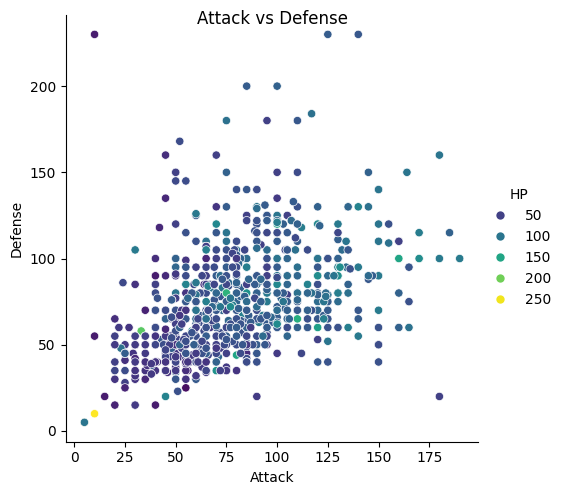

In [3]:
# Your code here . . .
g = sns.relplot(
    data=df,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="viridis"
)

g.fig.suptitle("Attack vs Defense")
plt.show()

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

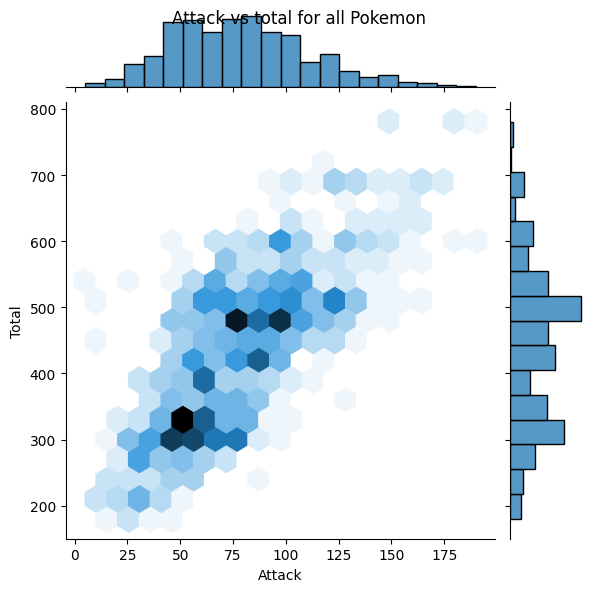

In [4]:
# Your code here . . .
g = sns.jointplot(
    data=df,
    x="Attack",
    y="Total",
    kind="hex"
)

g.fig.suptitle("Attack vs total for all Pokemon")
plt.show()

From the plot, I observed that there is a strong positive relationship between `Attack` and `Total`. It also displays the density of points using hexagonal bins, meaning darker hexagons represent areas where many Pokemon share similar `Attack` and `Total` values. This helps identify clusters and shows that most Pokemon fall within moderate attack and total stat ranges.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

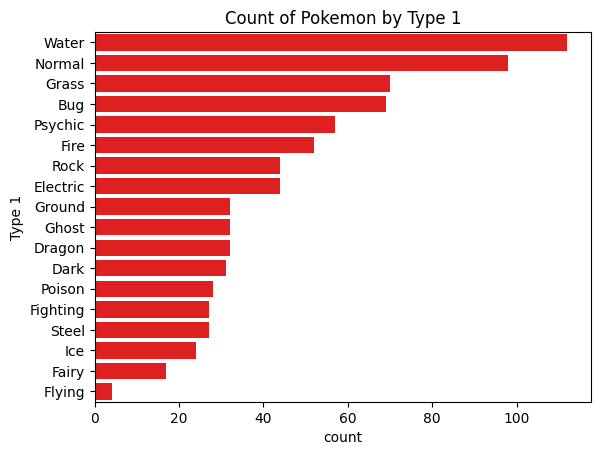

In [5]:
# Your code here . . .
sns.countplot(
    data=df,
    y="Type 1",
    order=df["Type 1"].value_counts().index,
    color="red"
)

plt.title("Count of Pokemon by Type 1")
plt.show()

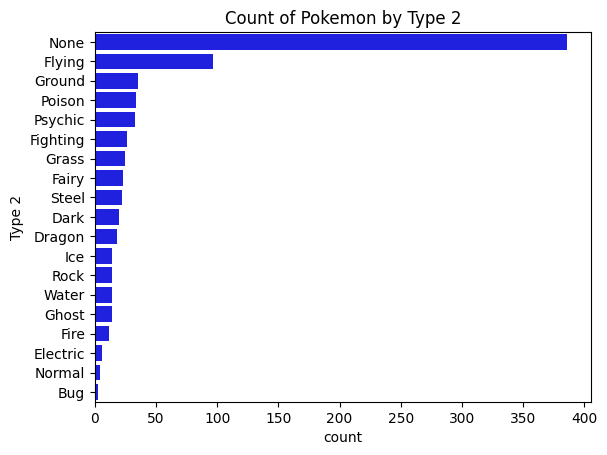

In [6]:
df["Type 2"] = df["Type 2"].fillna("None")

sns.countplot(
    data=df,
    y="Type 2",
    order=df["Type 2"].value_counts().index,
    color="blue"
)

plt.title("Count of Pokemon by Type 2")
plt.show()

From the plots, I observed that:
- The most common `Type 1` Pokemon is Water (followed by Normal and Grass)
- The rarest `Type 1` Pokemon types appear to be Fairy and Flying
- For `Type 2`, Flying is the most common secondary type
- Many Pokemon do not have a secondary type

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

# Q4: Are Legendary Pokemon stronger than non-Legendary Pokemon?

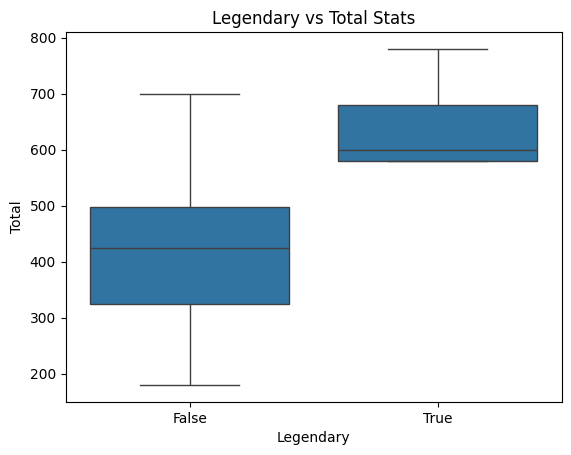

In [7]:
# Your code here . . .
sns.boxplot(
    data=df,
    x="Legendary",
    y="Total"
)

plt.title("Legendary vs Total Stats")
plt.show()

From the plot, I observed that legendary Pokemon have much higher total stats compared to non-legenday Pokemon.

# Q5: Which Generation has the strongest Pokeon on average?


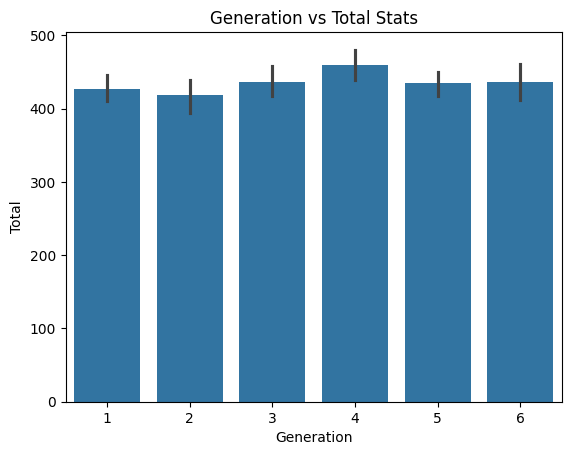

In [8]:
sns.barplot(
    data=df,
    x="Generation",
    y="Total"
)

plt.title("Generation vs Total Stats")
plt.show()

From the plot, I observed that later generations have slightly higher average total stats, though the differences are not that large.

# Which Pokemon Type 1 has the highest average HP?

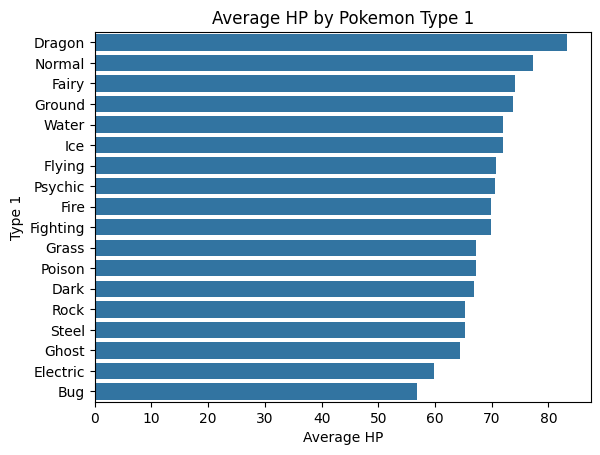

In [9]:
avg_hp = df.groupby("Type 1")["HP"].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_hp.values,
    y=avg_hp.index
)

plt.title("Average HP by Pokemon Type 1")
plt.xlabel("Average HP")
plt.ylabel("Type 1")
plt.show()

From the plot, I observed that among `Type 1` Pokemon, Dragon type Pokemon tend to have the highest average HP, followed by Normal and Fairy types. The lowest average HP among `Type 1` are Bug, Electric, and Ghost types.